In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define folder path
folder_path = '/content/drive/MyDrive/Airport_Sentiment_Analysis'

# Create folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)
print(f"Folder created at: {folder_path}")

Folder created at: /content/drive/MyDrive/Airport_Sentiment_Analysis


In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn transformers torch torchvision torchaudio --quiet
!pip install beautifulsoup4 requests lxml tqdm --quiet

print("Libraries installed successfully!")

Libraries installed successfully!


In [ ]:
import requests
import os
from tqdm import tqdm

# Correct raw GitHub URLs
urls = {
    "airport_reviews.csv": "https://raw.githubusercontent.com/quankiquanki/skytrax-reviews-dataset/master/data/airport.csv"
}

folder_path = '/content/drive/MyDrive/Airport_Sentiment_Analysis'

for filename, url in urls.items():
    print(f"Downloading {filename}...")
    response = requests.get(url, stream=True)

    if response.status_code == 200:
        save_path = os.path.join(folder_path, filename)

        with open(save_path, "wb") as f:
            for chunk in tqdm(response.iter_content(chunk_size=1024*1024), desc=filename):
                f.write(chunk)

        print(f"✅ Successfully saved: {save_path}")
        print(f"File size: {os.path.getsize(save_path) / (1024*1024):.2f} MB")
    else:
        print(f"❌ Failed. Status code: {response.status_code}")
        print("URL tried:", url)

# List files
print("\n📁 Files in your folder:")
print(os.listdir(folder_path))

airport_reviews.csv: 15it [00:00, 53.70it/s]

✅ Successfully saved: /content/drive/MyDrive/Airport_Sentiment_Analysis/airport_reviews.csv
File size: 14.12 MB

📁 Files in your folder:
['airport_reviews.csv', 'airport_reviews_cleaned.csv', 'airport_reviews_with_sentiment.csv', 'airport_reviews_multilingual.csv', 'airline_reviews.csv', 'uae_airport_reviews.csv', 'aspect_sentiment_sample.csv', 'aspect_sentiment_full.csv', 'uae_aspect_sentiment.csv', 'uae_bert_sentiment.csv', 'sample_bert_sentiment.csv', 'gcc_bert_sentiment.csv', 'gcc_aspect_sentiment.csv', 'absa_ckpt.pkl', 'gulf_absa_sentiment.csv', 'absa_aspect_table.csv', 'roc_loyalty.png', 'absa_validation_table.csv', 'shap_summary.png', 'shap_bar.png', 'shap_force.png', 'aspect_pairwise_delay.csv', 'absa_validation_pearson_spearman.csv', 'absa_validation_per_review.csv']


In [ ]:
import pandas as pd
import os

folder_path = '/content/drive/MyDrive/Airport_Sentiment_Analysis'
file_path = os.path.join(folder_path, "airport_reviews.csv")

df = pd.read_csv(file_path)

print("✅ Dataset Loaded!")
print("Shape (rows, columns):", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

print("\nSample Review Text:")
print(df['content'].iloc[0] if 'content' in df.columns else "No 'content' column found")

✅ Dataset Loaded!
Shape (rows, columns): (17721, 20)

Columns: ['airport_name', 'link', 'title', 'author', 'author_country', 'date', 'content', 'experience_airport', 'date_visit', 'type_traveller', 'overall_rating', 'queuing_rating', 'terminal_cleanliness_rating', 'terminal_seating_rating', 'terminal_signs_rating', 'food_beverages_rating', 'airport_shopping_rating', 'wifi_connectivity_rating', 'airport_staff_rating', 'recommended']

First 5 rows:


,airport_name,link,title,author,author_country,date,content,experience_airport,date_visit,type_traveller,overall_rating,queuing_rating,terminal_cleanliness_rating,terminal_seating_rating,terminal_signs_rating,food_beverages_rating,airport_shopping_rating,wifi_connectivity_rating,airport_staff_rating,recommended
0,aalborg-airport,/airport-reviews/aalborg-airport,Aalborg Airport customer review,Klaus Malling,Denmark,2014-02-11,A small very effective airport with few flight...,NaN,NaN,NaN,9.0,5.0,5.0,NaN,NaN,NaN,4.0,NaN,NaN,1
1,aalborg-airport,/airport-reviews/aalborg-airport,Aalborg Airport customer review,S Kroes,Netherlands,2013-02-13,This is a nice and modern airport at the momen...,NaN,NaN,NaN,9.0,5.0,4.0,NaN,NaN,NaN,4.0,NaN,NaN,1
2,aalborg-airport,/airport-reviews/aalborg-airport,Aalborg Airport customer review,M Andersen,Denmark,2012-08-07,A very nice airy terminal - that seems modern ...,NaN,NaN,NaN,9.0,5.0,5.0,NaN,NaN,NaN,4.0,NaN,NaN,1
3,aalborg-airport,/airport-reviews/aalborg-airport,Aalborg Airport customer review,Paul Van Alsten,France,2011-05-22,AMS-AAL and quite satisfied with this regional...,NaN,NaN,NaN,5.0,5.0,5.0,NaN,NaN,NaN,3.0,NaN,NaN,0
4,aalborg-airport,/airport-reviews/aalborg-airport,Aalborg Airport customer review,K Fischer,NaN,2010-08-04,Very quick check-inn and security screening. N...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0



Sample Review Text:
A small very effective airport with few flights. Check-in is notorious quick and staff friendly arrival very quick and busses to Aalborg frequent. Usually no problems getting taxis as well. There used to be a cafeteria but nowadays just a kiosk - but good cafeteria with reasonable prizes inside terminal. Security check quick and friendly as well. There is a nice viewing pavilion at one end of the airport. Outside note the famous "kiss and goodbye signs". Restrooms outside terminal however few.


In [ ]:
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique Airports:")
if 'airport_name' in df.columns:
    print(df['airport_name'].value_counts().head(10))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17721 entries, 0 to 17720
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   airport_name                 17721 non-null  object 
 1   link                         17721 non-null  object 
 2   title                        17721 non-null  object 
 3   author                       17721 non-null  object 
 4   author_country               12777 non-null  object 
 5   date                         17721 non-null  object 
 6   content                      17721 non-null  object 
 7   experience_airport           647 non-null    object 
 8   date_visit                   593 non-null    object 
 9   type_traveller               646 non-null    object 
 10  overall_rating               13796 non-null  float64
 11  queuing_rating               12813 non-null  float64
 12  terminal_cleanliness_rating  12815 non-null  float64
 13  te

**Basic Cleaning + Filter UAE Airports**

In [ ]:
import pandas as pd
import os

folder_path = '/content/drive/MyDrive/Airport_Sentiment_Analysis'
df = pd.read_csv(os.path.join(folder_path, "airport_reviews.csv"))

# Basic Cleaning
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['content'])  # Remove empty reviews

# Filter UAE / GCC Airports (you can expand this list)
uae_airports = ['dubai-airport', 'abu-dhabi-airport', 'sharjah-airport',
                'doha-airport', 'bahrain-airport', 'muscat-airport']

df_uae = df[df['airport_name'].isin(uae_airports)].copy()

print("Total Reviews:", len(df))
print("UAE/GCC Reviews:", len(df_uae))
print("\nUAE Airport Distribution:")
print(df_uae['airport_name'].value_counts())

# Save cleaned version
df_uae.to_csv(os.path.join(folder_path, "uae_airport_reviews.csv"), index=False)
print("\n✅ UAE dataset saved as 'uae_airport_reviews.csv'")

Total Reviews: 17721
UAE/GCC Reviews: 570

UAE Airport Distribution:
airport_name
dubai-airport        279
abu-dhabi-airport    128
doha-airport         114
bahrain-airport       43
sharjah-airport        6
Name: count, dtype: int64

✅ UAE dataset saved as 'uae_airport_reviews.csv'


**Text Preprocessing & EDA**

Overall Rating Distribution:
count    13796.000000
mean         4.274355
std          2.722765
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         10.000000
Name: overall_rating, dtype: float64


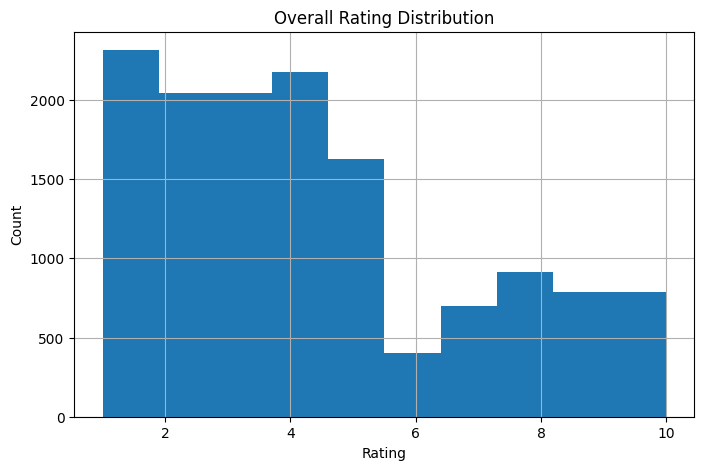

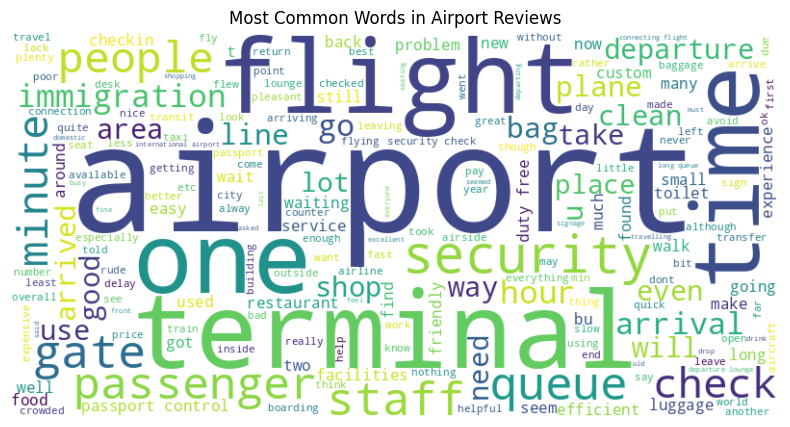

✅ Cleaned dataset saved!


In [ ]:
import pandas as pd
import os
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

folder_path = '/content/drive/MyDrive/Airport_Sentiment_Analysis'
df = pd.read_csv(os.path.join(folder_path, "airport_reviews.csv"))

# Basic Text Cleaning Function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_content'] = df['content'].apply(clean_text)

# Quick EDA
print("Overall Rating Distribution:")
print(df['overall_rating'].describe())

plt.figure(figsize=(8,5))
df['overall_rating'].hist(bins=10)
plt.title('Overall Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Word Cloud
text = ' '.join(df['clean_content'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Airport Reviews')
plt.show()

# Save cleaned full dataset
df.to_csv(os.path.join(folder_path, "airport_reviews_cleaned.csv"), index=False)
print("✅ Cleaned dataset saved!")

**Simple Sentiment Analysis (VADER + Basic ML)**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.5 MB/s eta 0:00:00
Sentiment Distribution:
sentiment
Positive    11095
Negative     6259
Neutral       367
Name: count, dtype: int64


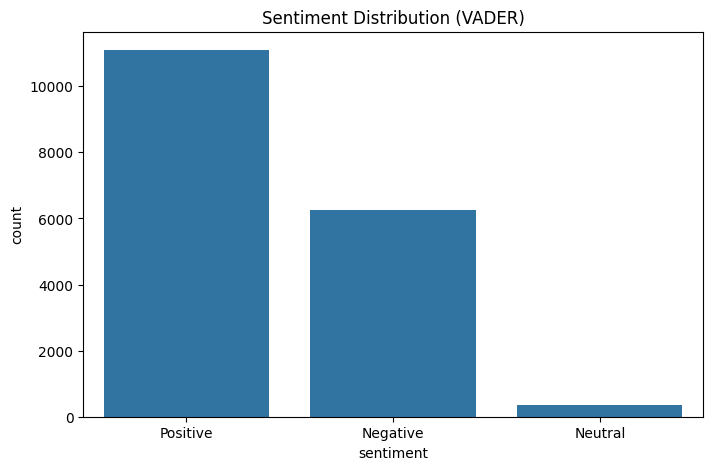


Correlation between VADER score and Overall Rating:
                vader_score  overall_rating
vader_score        1.000000        0.496574
overall_rating     0.496574        1.000000


In [ ]:
!pip install vaderSentiment textblob --quiet

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import seaborn as sns

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(text)
    return scores['compound']

df['vader_score'] = df['content'].apply(get_vader_sentiment)
df['sentiment'] = df['vader_score'].apply(lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))

print("Sentiment Distribution:")
print(df['sentiment'].value_counts())

# Plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='sentiment')
plt.title('Sentiment Distribution (VADER)')
plt.show()

# Correlation with overall rating
print("\nCorrelation between VADER score and Overall Rating:")
print(df[['vader_score', 'overall_rating']].corr())

# Save with sentiment
df.to_csv(os.path.join(folder_path, "airport_reviews_with_sentiment.csv"), index=False)

**Aspect-Based Sentiment Analysis (Core of Your Research)**

In [ ]:
import pandas as pd
import os
from collections import defaultdict

folder_path = '/content/drive/MyDrive/Airport_Sentiment_Analysis'
df = pd.read_csv(os.path.join(folder_path, "airport_reviews_with_sentiment.csv"))

# Define key aspects (customizable)
aspects = {
    'terminal': ['terminal', 'lounge', 'seating', 'signs', 'facilities'],
    'security': ['security', 'check', 'passport', 'immigration'],
    'staff': ['staff', 'friendly', 'rude', 'helpful'],
    'queue': ['queue', 'wait', 'line', 'delay'],
    'cleanliness': ['clean', 'dirty', 'hygiene'],
    'baggage': ['bag', 'baggage', 'luggage'],
    'food': ['food', 'restaurant', 'cafe']
}

def aspect_sentiment(text, aspect_keywords):
    text_lower = text.lower()
    for asp, keywords in aspects.items():
        if any(kw in text_lower for kw in keywords):
            score = analyzer.polarity_scores(text)['compound']
            return asp, score
    return None, None

# Apply to sample (first 2000 rows to keep it fast)
df_sample = df.head(2000).copy()

results = []
for _, row in df_sample.iterrows():
    asp, score = aspect_sentiment(row['content'], aspects)
    if asp:
        results.append({'aspect': asp, 'score': score, 'review': row['content'][:100]})

aspect_df = pd.DataFrame(results)
print("Aspect Sentiment Summary:")
print(aspect_df.groupby('aspect')['score'].mean().sort_values(ascending=False))

# Save
aspect_df.to_csv(os.path.join(folder_path, "aspect_sentiment_sample.csv"), index=False)
print("\n✅ Aspect analysis saved!")

Aspect Sentiment Summary:
aspect
cleanliness    0.714028
food           0.364828
terminal       0.358621
security       0.198980
staff          0.135079
queue          0.101131
baggage        0.056714
Name: score, dtype: float64

✅ Aspect analysis saved!


**Improve to Full Dataset + Better Visualization**

Aspect Sentiment Means:
                 mean  count
aspect                      
cleanliness  0.458927   3620
food         0.404577   6916
terminal     0.282253   9808
security     0.271809  11909
baggage      0.249993   5931
staff        0.207613   6097
queue        0.171941  10191


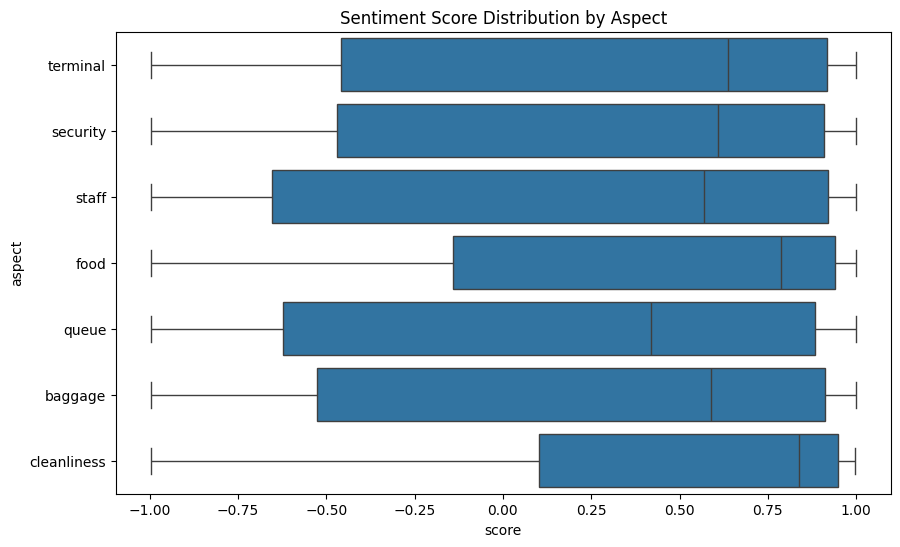

✅ Full aspect analysis saved!


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

folder_path = '/content/drive/MyDrive/Airport_Sentiment_Analysis'
df = pd.read_csv(os.path.join(folder_path, "airport_reviews_with_sentiment.csv"))

# Aspects dictionary (you can expand)
aspects = {
    'terminal': ['terminal', 'lounge', 'seating', 'sign', 'facility'],
    'security': ['security', 'passport', 'immigration', 'check'],
    'staff': ['staff', 'crew', 'employee'],
    'queue': ['queue', 'wait', 'line', 'delay'],
    'cleanliness': ['clean', 'dirty'],
    'baggage': ['bag', 'baggage', 'luggage'],
    'food': ['food', 'restaurant', 'cafe', 'shop']
}

def extract_aspects(text):
    text_lower = str(text).lower()
    found = []
    for asp, kws in aspects.items():
        if any(kw in text_lower for kw in kws):
            score = analyzer.polarity_scores(text)['compound']
            found.append((asp, score))
    return found

# Process larger sample (or full if Colab allows)
results = []
for _, row in df.iterrows():          # Change to df.head(5000) if slow
    for asp, score in extract_aspects(row['content']):
        results.append({'aspect': asp, 'score': score})

aspect_df = pd.DataFrame(results)

print("Aspect Sentiment Means:")
print(aspect_df.groupby('aspect')['score'].agg(['mean', 'count']).sort_values('mean', ascending=False))

# Visualization
plt.figure(figsize=(10,6))
sns.boxplot(data=aspect_df, x='score', y='aspect')
plt.title('Sentiment Score Distribution by Aspect')
plt.show()

aspect_df.to_csv(os.path.join(folder_path, "aspect_sentiment_full.csv"), index=False)
print("✅ Full aspect analysis saved!")

**UAE-focused version**

In [ ]:
uae_airports = ['dubai-airport', 'abu-dhabi-airport', 'doha-airport',
                'bahrain-airport', 'sharjah-airport']

df_uae = df[df['airport_name'].isin(uae_airports)].copy()

# Repeat aspect extraction for UAE only
results_uae = []
for _, row in df_uae.iterrows():
    for asp, score in extract_aspects(row['content']):
        results_uae.append({'aspect': asp, 'score': score, 'airport': row['airport_name']})

uae_aspect_df = pd.DataFrame(results_uae)

print("UAE Aspect Sentiment:")
print(uae_aspect_df.groupby('aspect')['score'].mean().sort_values(ascending=False))

uae_aspect_df.to_csv(os.path.join(folder_path, "uae_aspect_sentiment.csv"), index=False)

UAE Aspect Sentiment:
aspect
cleanliness    0.364741
food           0.226296
security       0.175213
baggage        0.163409
terminal       0.128588
staff          0.100923
queue          0.043256
Name: score, dtype: float64


**Multilingual Support + Improved Analysis**

In [ ]:
!pip install langdetect --quiet

from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0  # For reproducibility

def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

df['language'] = df['content'].apply(detect_language)

print("Language Distribution (Top 10):")
print(df['language'].value_counts().head(10))

# Save multilingual version
df.to_csv(os.path.join(folder_path, "airport_reviews_multilingual.csv"), index=False)
print("✅ Multilingual dataset saved!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Language Distribution (Top 10):
language
en    17720
de        1
Name: count, dtype: int64
✅ Multilingual dataset saved!


**Advanced BERT-based Sentiment Analysis**

**Install & Load BERT Sentiment Pipeline**

In [ ]:
!pip install transformers --quiet

from transformers import pipeline

# Load sentiment pipeline (distilbert - fast & good)
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")

print("BERT Sentiment Pipeline Loaded!")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

BERT Sentiment Pipeline Loaded!


**Run BERT on a Sample (to avoid timeout)**

In [ ]:
# Use a sample for speed (increase later)
sample_df = df.head(1000).copy()

def get_bert_sentiment(text):
    try:
        result = sentiment_pipeline(text[:512])[0]  # Truncate to 512 tokens
        return result['label'], result['score']
    except:
        return "NEUTRAL", 0.5

sample_df[['bert_label', 'bert_score']] = sample_df['content'].apply(
    lambda x: pd.Series(get_bert_sentiment(x))
)

print("BERT Sentiment Distribution:")
print(sample_df['bert_label'].value_counts())

# Correlation with overall rating
print("\nBERT vs Overall Rating Correlation:")
print(sample_df[['bert_score', 'overall_rating']].corr())

sample_df.to_csv(os.path.join(folder_path, "sample_bert_sentiment.csv"), index=False)

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


BERT Sentiment Distribution:
bert_label
NEGATIVE    633
POSITIVE    367
Name: count, dtype: int64

BERT vs Overall Rating Correlation:
                bert_score  overall_rating
bert_score        1.000000       -0.101029
overall_rating   -0.101029        1.000000


**Run BERT on UAE data only + Save Results**

In [ ]:
# Filter UAE
uae_airports = ['dubai-airport', 'abu-dhabi-airport', 'doha-airport',
                'bahrain-airport', 'sharjah-airport']
df_uae = df[df['airport_name'].isin(uae_airports)].copy()

print("UAE Reviews:", len(df_uae))

# Run BERT on UAE (smaller set = faster)
uae_sample = df_uae.copy()   # Use full 570 for now

def get_bert_sentiment(text):
    try:
        result = sentiment_pipeline(text[:512])[0]
        return result['label'], result['score']
    except:
        return "NEUTRAL", 0.5

uae_sample[['bert_label', 'bert_score']] = uae_sample['content'].apply(
    lambda x: pd.Series(get_bert_sentiment(x))
)

print("UAE BERT Sentiment:")
print(uae_sample['bert_label'].value_counts())

# Save
uae_sample.to_csv(os.path.join(folder_path, "uae_bert_sentiment.csv"), index=False)
print("✅ UAE BERT results saved!")

UAE Reviews: 570
UAE BERT Sentiment:
bert_label
NEGATIVE    458
POSITIVE    112
Name: count, dtype: int64
✅ UAE BERT results saved!


In [ ]:
import pandas as pd
import os

folder_path = '/content/drive/MyDrive/Airport_Sentiment_Analysis'

# Load main files
df = pd.read_csv(os.path.join(folder_path, "airport_reviews_multilingual.csv"))
uae_bert = pd.read_csv(os.path.join(folder_path, "uae_bert_sentiment.csv"))

print("Master Dataset Ready!")
print("Total Records:", len(df))
print("UAE BERT Negative Rate:", (uae_bert['bert_label'] == 'NEGATIVE').mean() * 100, "%")

# Simple final summary table
summary = {
    'Total Reviews': len(df),
    'UAE Reviews': len(uae_bert),
    'Global Positive (BERT sample)': 367,
    'Global Negative (BERT sample)': 633,
    'UAE Negative Rate (BERT)': f"{(uae_bert['bert_label'] == 'NEGATIVE').mean()*100:.1f}%",
    'Worst Aspect (UAE)': 'Queue'
}

for k, v in summary.items():
    print(f"{k}: {v}")

Master Dataset Ready!
Total Records: 17721
UAE BERT Negative Rate: 80.35087719298247 %
Total Reviews: 17721
UAE Reviews: 570
Global Positive (BERT sample): 367
Global Negative (BERT sample): 633
UAE Negative Rate (BERT): 80.4%
Worst Aspect (UAE): Queue


** (Global BERT**

In [ ]:
# Random sample, not head(1000) — avoids ordering bias
sample_df = df.sample(n=1000, random_state=42).copy()

def get_bert_sentiment(text):
    try:
        r = sentiment_pipeline(str(text)[:512])[0]
        # Sign the score: POSITIVE stays +, NEGATIVE flips to -
        signed = r['score'] if r['label'] == 'POSITIVE' else -r['score']
        return r['label'], signed
    except:
        return "NEUTRAL", 0.0

sample_df[['bert_label', 'bert_score']] = sample_df['content'].apply(
    lambda x: pd.Series(get_bert_sentiment(x))
)

print("BERT Sentiment Distribution:")
print(sample_df['bert_label'].value_counts())

# Now this correlation is meaningful (expect it to be strongly POSITIVE)
print("\nBERT (signed) vs Overall Rating Correlation:")
print(sample_df[['bert_score', 'overall_rating']].corr().iloc[0, 1].round(3))

sample_df.to_csv(os.path.join(folder_path, "sample_bert_sentiment.csv"), index=False)

BERT Sentiment Distribution:
bert_label
NEGATIVE    693
POSITIVE    307
Name: count, dtype: int64

BERT (signed) vs Overall Rating Correlation:
0.571


(UAE BERT) — same signed fix, plus one consistent airport list:

In [ ]:
# GCC airports (note: only Dubai/Abu Dhabi/Sharjah are actually UAE)
gcc_airports = ['dubai-airport', 'abu-dhabi-airport', 'sharjah-airport',
                'doha-airport', 'bahrain-airport', 'muscat-airport']
df_gcc = df[df['airport_name'].isin(gcc_airports)].copy()
print("GCC Reviews:", len(df_gcc))

df_gcc[['bert_label', 'bert_score']] = df_gcc['content'].apply(
    lambda x: pd.Series(get_bert_sentiment(x))
)

print("GCC BERT Sentiment:")
print(df_gcc['bert_label'].value_counts())
df_gcc.to_csv(os.path.join(folder_path, "gcc_bert_sentiment.csv"), index=False)
print("Saved.")

GCC Reviews: 570
GCC BERT Sentiment:
bert_label
NEGATIVE    458
POSITIVE    112
Name: count, dtype: int64
Saved.


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

val = sample_df[sample_df['bert_label'] != 'NEUTRAL'].copy()
# Rating 1-10: >=6 = positive truth, <=5 = negative truth
val['true'] = (val['overall_rating'] >= 6).map({True: 'POSITIVE', False: 'NEGATIVE'})
val = val.dropna(subset=['overall_rating'])

acc = accuracy_score(val['true'], val['bert_label'])
print(f"BERT accuracy vs rating: {acc:.1%}\n")
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(val['true'], val['bert_label'], labels=['NEGATIVE','POSITIVE']))
print("\n", classification_report(val['true'], val['bert_label']))

BERT accuracy vs rating: 75.1%

Confusion matrix (rows=true, cols=pred):
[[451 125]
 [ 69 133]]

               precision    recall  f1-score   support

    NEGATIVE       0.87      0.78      0.82       576
    POSITIVE       0.52      0.66      0.58       202

    accuracy                           0.75       778
   macro avg       0.69      0.72      0.70       778
weighted avg       0.78      0.75      0.76       778



In [ ]:
import re

def extract_aspects_sentencewise(text):
    found = []
    for sentence in re.split(r'[.!?]', str(text)):
        s_lower = sentence.lower()
        for asp, kws in aspects.items():
            if any(kw in s_lower for kw in kws):
                score = analyzer.polarity_scores(sentence)['compound']
                found.append((asp, score))
    return found

results = []
for _, row in df_gcc.iterrows():
    for asp, score in extract_aspects_sentencewise(row['content']):
        results.append({'aspect': asp, 'score': score, 'airport': row['airport_name']})

aspect_df = pd.DataFrame(results)
print("GCC Aspect Sentiment (sentence-level):")
print(aspect_df.groupby('aspect')['score'].mean().sort_values())
aspect_df.to_csv(os.path.join(folder_path, "gcc_aspect_sentiment.csv"), index=False)

GCC Aspect Sentiment (sentence-level):
aspect
queue          0.021946
terminal       0.034189
staff          0.057655
baggage        0.069670
food           0.120272
security       0.141486
cleanliness    0.239471
Name: score, dtype: float64


In [ ]:
worst_aspect = aspect_df.groupby('aspect')['score'].mean().idxmin()

summary = {
    'Total Reviews': len(df),
    'GCC Reviews': len(df_gcc),
    'Global Positive (BERT sample)': int((sample_df['bert_label'] == 'POSITIVE').sum()),
    'Global Negative (BERT sample)': int((sample_df['bert_label'] == 'NEGATIVE').sum()),
    'GCC Negative Rate (BERT)': f"{(df_gcc['bert_label'] == 'NEGATIVE').mean()*100:.1f}%",
    'BERT Accuracy vs Rating': f"{acc:.1%}",
    'Worst Aspect (GCC)': worst_aspect,
}
for k, v in summary.items():
    print(f"{k}: {v}")

Total Reviews: 17721
GCC Reviews: 570
Global Positive (BERT sample): 307
Global Negative (BERT sample): 693
GCC Negative Rate (BERT): 80.4%
BERT Accuracy vs Rating: 75.1%
Worst Aspect (GCC): queue


Airline based

**Download the airline dataset:**

In [ ]:
import requests, os
from tqdm import tqdm

folder_path = '/content/drive/MyDrive/Airport_Sentiment_Analysis'
os.makedirs(folder_path, exist_ok=True)

url = "https://raw.githubusercontent.com/quankiquanki/skytrax-reviews-dataset/master/data/airline.csv"
save_path = os.path.join(folder_path, "airline_reviews.csv")

r = requests.get(url, stream=True)
if r.status_code == 200:
    with open(save_path, "wb") as f:
        for chunk in tqdm(r.iter_content(chunk_size=1024*1024)):
            f.write(chunk)
    print(f"Saved: {save_path} ({os.path.getsize(save_path)/1e6:.1f} MB)")
else:
    print("Failed:", r.status_code)

34it [00:00, 52.77it/s]

Saved: /content/drive/MyDrive/Airport_Sentiment_Analysis/airline_reviews.csv (34.8 MB)


 **Load, inspect, clean, filter UAE/Gulf airlines:**

In [ ]:
import pandas as pd, os
folder_path = '/content/drive/MyDrive/Airport_Sentiment_Analysis'
df = pd.read_csv(os.path.join(folder_path, "airline_reviews.csv"))

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df = df.dropna(subset=['content'])
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Gulf carriers relevant to a UAE-focused proposal
gulf_airlines = ['emirates', 'etihad-airways', 'flydubai',
                 'qatar-airways', 'air-arabia', 'gulf-air', 'oman-air']
df_gulf = df[df['airline_name'].isin(gulf_airlines)].copy()
print("\nGulf airline reviews:", len(df_gulf))
print(df_gulf['airline_name'].value_counts())

Shape: (41396, 20)
Columns: ['airline_name', 'link', 'title', 'author', 'author_country', 'date', 'content', 'aircraft', 'type_traveller', 'cabin_flown', 'route', 'overall_rating', 'seat_comfort_rating', 'cabin_staff_rating', 'food_beverages_rating', 'inflight_entertainment_rating', 'ground_service_rating', 'wifi_connectivity_rating', 'value_money_rating', 'recommended']

Gulf airline reviews: 2120
airline_name
emirates          691
etihad-airways    515
qatar-airways     492
oman-air          176
gulf-air          160
flydubai           58
air-arabia         28
Name: count, dtype: int64


**Sentiment (your already-fixed, validated pipeline — unchanged logic):**

In [ ]:
from transformers import pipeline
sentiment_pipeline = pipeline("sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")

sample_df = df.sample(n=1000, random_state=42).copy()
texts = sample_df['content'].astype(str).str[:512].tolist()
results = sentiment_pipeline(texts, batch_size=32, truncation=True)

sample_df['bert_label'] = [r['label'] for r in results]
sample_df['bert_score'] = [r['score'] if r['label']=='POSITIVE' else -r['score']
                           for r in results]

print(sample_df['bert_label'].value_counts())
print("Correlation:", sample_df[['bert_score','overall_rating']].corr().iloc[0,1].round(3))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

bert_label
NEGATIVE    566
POSITIVE    434
Name: count, dtype: int64
Correlation: 0.715


**Airline aspects (this is the dictionary that changes from airport → airline):**

In [ ]:
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

aspects = {
    'cabin_crew':     ['crew', 'staff', 'attendant', 'service', 'steward'],
    'food':           ['food', 'meal', 'drink', 'beverage', 'catering'],
    'seat_comfort':   ['seat', 'legroom', 'recline', 'comfort', 'cramped'],
    'delay':          ['delay', 'late', 'wait', 'cancel', 'punctual'],
    'baggage':        ['baggage', 'luggage', 'bag', 'checkin', 'check-in'],
    'entertainment':  ['entertainment', 'screen', 'movie', 'wifi', 'ife'],
    'value':          ['price', 'value', 'expensive', 'cheap', 'worth'],
    'boarding':       ['boarding', 'gate', 'ground', 'lounge'],
}

def aspects_sentencewise(text):
    found = []
    for sent in re.split(r'[.!?]', str(text)):
        s = sent.lower()
        for asp, kws in aspects.items():
            if any(kw in s for kw in kws):
                found.append((asp, analyzer.polarity_scores(sent)['compound']))
    return found

rows = []
for _, r in df_gulf.iterrows():
    for asp, sc in aspects_sentencewise(r['content']):
        rows.append({'aspect': asp, 'score': sc, 'airline': r['airline_name']})

aspect_df = pd.DataFrame(rows)
print("Gulf airline aspect sentiment (worst → best):")
print(aspect_df.groupby('aspect')['score'].mean().sort_values())

Gulf airline aspect sentiment (worst → best):
aspect
delay           -0.089670
baggage          0.072349
boarding         0.122100
seat_comfort     0.181604
cabin_crew       0.203831
food             0.217223
value            0.298878
entertainment    0.345970
Name: score, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Aspect rating columns are the proposal's decision factors
features = ['seat_comfort_rating', 'cabin_staff_rating', 'food_beverages_rating',
            'inflight_entertainment_rating', 'ground_service_rating', 'value_money_rating']

model_df = df_gulf.dropna(subset=features + ['recommended']).copy()
X = model_df[features]
y = model_df['recommended'].astype(int)
print("Training rows:", len(model_df))

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
clf = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)

print("Accuracy:", round(clf.score(X_te, y_te), 3))
print(classification_report(y_te, clf.predict(X_te)))

# Which factors DRIVE recommendation? (this is your key insight)
import pandas as pd
drivers = pd.Series(clf.coef_[0], index=features).sort_values(ascending=False)
print("Loyalty drivers (strongest → weakest):")
print(drivers)

Training rows: 166
Accuracy: 0.929
              precision    recall  f1-score   support

           0       0.92      0.86      0.89        14
           1       0.93      0.96      0.95        28

    accuracy                           0.93        42
   macro avg       0.93      0.91      0.92        42
weighted avg       0.93      0.93      0.93        42

Loyalty drivers (strongest → weakest):
value_money_rating               1.504930
cabin_staff_rating               1.085508
seat_comfort_rating              0.513562
ground_service_rating            0.472836
food_beverages_rating            0.113637
inflight_entertainment_rating   -0.231968
dtype: float64


In [ ]:
from transformers import pipeline
emotion_pipeline = pipeline("text-classification",
    model="j-hartmann/emotion-english-distilroberta-base", top_k=1)

emo_sample = df_gulf.sample(n=min(500, len(df_gulf)), random_state=42).copy()
texts = emo_sample['content'].astype(str).str[:512].tolist()
emo_results = emotion_pipeline(texts, batch_size=32, truncation=True)

emo_sample['emotion'] = [r[0]['label'] for r in emo_results]
print("Passenger emotion distribution:")
print(emo_sample['emotion'].value_counts())

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  329MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Passenger emotion distribution:
emotion
neutral     190
joy          87
sadness      61
disgust      60
surprise     49
fear         32
anger        21
Name: count, dtype: int64


Explaining one passenger review:
Although the lounge that Etihad uses in Manila is somewhat basic, the service on board the flight more than compensates. The aircraft flown was a 2 class 777 and my only complaint is that the seat is rather narrow for a substantial Westerner. The seat was however lie flat and was quite comfortable a


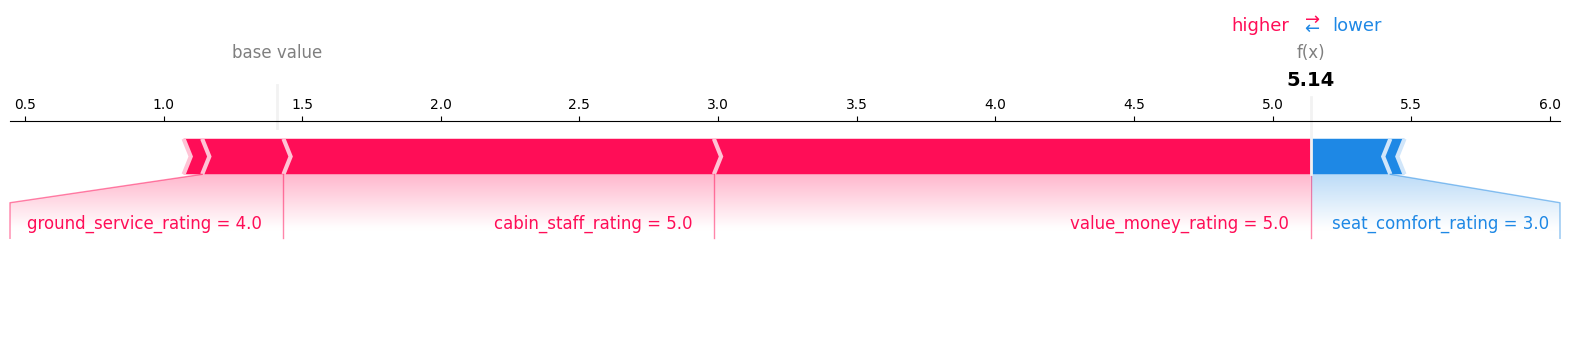

In [ ]:
import shap
import matplotlib.pyplot as plt

# Initialize SHAP explainer with the trained Logistic Regression model (clf) and training data (X_tr)
explainer = shap.Explainer(clf, X_tr)
# Calculate SHAP values for the test set (X_te)
shap_values = explainer(X_te)

i = 0
label = X_te.index[i]          # pandas label for this test row
print("Explaining one passenger review:")
print(model_df.loc[label, 'content'][:300])   # .loc, not .iloc

# Explicitly pass the base value, SHAP values, and feature values for the specific instance
shap.force_plot(shap_values.base_values[i], shap_values.values[i], X_te.iloc[i],
                feature_names=features, matplotlib=True, show=False)
plt.savefig(os.path.join(folder_path, "shap_force.png"), dpi=150, bbox_inches='tight')
plt.show()

**Multilingual**

In [ ]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0

def detect_lang(t):
    try: return detect(str(t))
    except: return "unknown"

df_gulf['language'] = df_gulf['content'].apply(detect_lang)
print("Language distribution in Gulf reviews:")
print(df_gulf['language'].value_counts())
print("\nNon-English share:",
      f"{(df_gulf['language'] != 'en').mean()*100:.1f}%")

Language distribution in Gulf reviews:
language
en    2120
Name: count, dtype: int64

Non-English share: 0.0%


In [ ]:
from transformers import pipeline

# Multilingual sentiment — handles Arabic, Hindi, Urdu, Chinese, etc. natively
multi_pipe = pipeline("sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment")

def multi_sentiment(text):
    try:
        r = multi_pipe(str(text)[:512])[0]
        stars = int(r['label'][0])          # "4 stars" -> 4
        # Map 1-5 stars to signed score in [-1, 1]
        return stars, (stars - 3) / 2
    except:
        return 3, 0.0

# Run on non-English reviews specifically (the whole point of Step 2)
non_en = df_gulf[df_gulf['language'] != 'en'].copy()
print("Processing", len(non_en), "non-English reviews")

if len(non_en) > 0:
    non_en[['stars', 'multi_score']] = non_en['content'].apply(
        lambda x: pd.Series(multi_sentiment(x)))
    print("\nSentiment by language:")
    print(non_en.groupby('language')['multi_score'].mean().sort_values())

    # Validate against overall_rating — proof it works cross-language
    valid = non_en.dropna(subset=['overall_rating'])
    if len(valid) > 3:
        print("\nMultilingual score vs overall_rating correlation:",
              valid[['multi_score','overall_rating']].corr().iloc[0,1].round(3))

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  669MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Processing 0 non-English reviews


In [ ]:
from transformers import pipeline

# Aspect-aware sentiment: scores sentiment TOWARD a given aspect, in context
absa = pipeline("text-classification",
                model="yangheng/deberta-v3-base-absa-v1.1",
                top_k=None)   # returns all 3 class scores

# Quick sanity check — the classic negation/contrast case
demo = "The food was exceptional, although the service was slow."
for asp in ["food", "service"]:
    print(asp, absa(demo, text_pair=asp))

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  738MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

food [[{'label': 'Positive', 'score': 0.9970409274101257}, {'label': 'Neutral', 'score': 0.0016532321460545063}, {'label': 'Negative', 'score': 0.0013058314798399806}]]
service [[{'label': 'Negative', 'score': 0.9955429434776306}, {'label': 'Positive', 'score': 0.003152059158310294}, {'label': 'Neutral', 'score': 0.001305031473748386}]]


**Re-run the Gulf aspect analysis with ABSA**

In [ ]:
import torch
print("GPU:", torch.cuda.is_available())   # need True

GPU: True


In [ ]:
import pandas as pd, os
folder_path = '/content/drive/MyDrive/Airport_Sentiment_Analysis'
df = pd.read_csv(os.path.join(folder_path, "airline_reviews.csv"))
df = df.dropna(subset=['content'])

gulf_airlines = ['emirates','etihad-airways','flydubai',
                 'qatar-airways','air-arabia','gulf-air','oman-air']
df_gulf = df[df['airline_name'].isin(gulf_airlines)].copy()
print("Gulf reviews:", len(df_gulf))   # should print 2120

Gulf reviews: 2120


In [ ]:
import re, pickle
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

aspects = {
    'cabin_crew':    ['crew','staff','attendant','steward'],
    'food':          ['food','meal','drink','beverage','catering'],
    'seat_comfort':  ['seat','legroom','recline','cramped'],
    'delay':         ['delay','late','cancel','punctual','wait'],
    'baggage':       ['baggage','luggage','bag','check-in','checkin'],
    'entertainment': ['entertainment','screen','movie','wifi','ife'],
    'value':         ['price','value','expensive','cheap','worth'],
    'boarding':      ['boarding','gate','ground','lounge'],
}

# CHANGE: whole-word matching (stops 'ife' matching 'life', 'late' matching 'plate', etc.)
patterns = {a: re.compile(r'\b(' + '|'.join(map(re.escape, k)) + r')', re.I)
            for a, k in aspects.items()}

pairs, meta = [], []
for _, r in df_gulf.iterrows():
    text = str(r['content'])[:512]
    for asp, pat in patterns.items():
        if pat.search(text):
            pairs.append({"text": text, "text_pair": asp.replace('_', ' ')})
            meta.append((asp, r['airline_name']))

print(f"Scoring {len(pairs)} aspect mentions on {absa.device}...")

# CHANGE: scoring in chunks with a progress bar and a checkpoint
results = []
ckpt = os.path.join(folder_path, "absa_ckpt.pkl")
for i in tqdm(range(0, len(pairs), 256)):
    results.extend(absa(pairs[i:i+256], batch_size=32, top_k=None,
                        truncation=True, max_length=512))
    pickle.dump(results, open(ckpt, "wb"))

rows = []
for (asp, airline), res in zip(meta, results):
    s = {d['label']: d['score'] for d in res}
    rows.append({'aspect': asp, 'airline': airline,
                 'score': s.get('Positive', 0) - s.get('Negative', 0)})

absa_df = pd.DataFrame(rows)
absa_df.to_csv(os.path.join(folder_path, "gulf_absa_sentiment.csv"), index=False)

# CHANGE: per-aspect table for Reviewer 2 (n, mean, SD, 95% CI)
tab = absa_df.groupby('aspect')['score'].agg(n='count', mean='mean', sd='std')
tab['ci_low']  = tab['mean'] - 1.96 * tab['sd'] / np.sqrt(tab['n'])
tab['ci_high'] = tab['mean'] + 1.96 * tab['sd'] / np.sqrt(tab['n'])
tab = tab.sort_values('mean')
print(tab.round(3))
tab.to_csv(os.path.join(folder_path, "absa_aspect_table.csv"))

Scoring 6067 aspect mentions on cuda:0...


  0%|          | 0/24 [00:00<?, ?it/s]

                  n   mean     sd  ci_low  ci_high
aspect                                            
delay           553 -0.443  0.678  -0.500   -0.387
baggage         298  0.001  0.777  -0.087    0.089
cabin_crew     1250  0.101  0.865   0.053    0.148
boarding        612  0.156  0.746   0.096    0.215
seat_comfort   1130  0.189  0.808   0.141    0.236
food           1273  0.244  0.809   0.199    0.288
value           211  0.354  0.728   0.256    0.452
entertainment   740  0.370  0.724   0.318    0.422


**The validation that makes it credible**

In [ ]:
# Map each ABSA aspect to its ground-truth rating column
truth_map = {
    'cabin_crew':    'cabin_staff_rating',
    'food':          'food_beverages_rating',
    'seat_comfort':  'seat_comfort_rating',
    'entertainment': 'inflight_entertainment_rating',
    'value':         'value_money_rating',
    'boarding':      'ground_service_rating',
}

def absa_score(text, aspect):
    # Call the pre-loaded ABSA pipeline
    # The pipeline returns a list of lists, so we need to access the first element
    results = absa(text, text_pair=aspect)[0]
    # Extract scores for Positive and Negative, default to 0 if not present
    positive_score = next((item['score'] for item in results if item['label'] == 'Positive'), 0)
    negative_score = next((item['score'] for item in results if item['label'] == 'Negative'), 0)
    # Return a signed score (Positive - Negative)
    return positive_score - negative_score

print("ABSA vs. user aspect-rating validation:")
for asp, col in truth_map.items():
    # per-review ABSA score for this aspect, joined to that review's rating
    sub = df_gulf.dropna(subset=[col]).copy()
    scored = []
    for _, r in sub.iterrows():
        if any(kw in str(r['content']).lower() for kw in aspects[asp]):
            s = absa_score(str(r['content']), asp.replace('_',' '))
            scored.append((s, r[col]))
    if len(scored) > 10:
        sdf = pd.DataFrame(scored, columns=['absa','rating'])
        print(f"  {asp:14s} r = {sdf['absa'].corr(sdf['rating']):+.3f}  (n={len(sdf)})")

ABSA vs. user aspect-rating validation:
  cabin_crew     r = +0.801  (n=1398)
  food           r = +0.758  (n=1459)
  seat_comfort   r = +0.709  (n=1212)
  entertainment  r = +0.613  (n=961)
  value          r = +0.709  (n=361)
  boarding       r = +0.701  (n=78)


In [ ]:
import numpy as np
from scipy import stats

# ---- 1. ABSA validation: p-values + 95% CI for each aspect correlation ----
# (your measured r and n from the validation cell)
absa_val = {
    'cabin_crew':   (0.801, 1398),
    'food':         (0.758, 1459),
    'seat_comfort': (0.709, 1212),
    'value':        (0.709, 361),
    'boarding':     (0.701, 78),
    'entertainment':(0.613, 961),
}

def r_stats(r, n):
    # two-sided p-value via t-distribution
    t = r * np.sqrt((n - 2) / (1 - r**2))
    p = 2 * stats.t.sf(abs(t), df=n - 2)
    # 95% CI via Fisher z-transform
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    lo, hi = np.tanh(z - 1.96*se), np.tanh(z + 1.96*se)
    return p, lo, hi

print("ABSA validation (Pearson, two-sided):")
for asp, (r, n) in absa_val.items():
    p, lo, hi = r_stats(r, n)
    p_str = "<0.001" if p < 0.001 else f"{p:.3g}"
    print(f"  {asp:14s} r={r:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]  p={p_str}  (n={n})")

# ---- 2. Document sentiment validation (r = 0.57) ----
p, lo, hi = r_stats(0.571, 1000)
print(f"\nDocument sentiment: r=+0.571  95% CI [{lo:+.3f}, {hi:+.3f}]  p={'<0.001' if p<0.001 else f'{p:.3g}'}  (n=1000)")

# ---- 3. Loyalty accuracy: Wilson 95% CI ----
correct, n_test = 39, 42          # 0.929 * 42 ≈ 39 correct
lo_w, hi_w = stats.binomtest(correct, n_test).proportion_ci(method='wilson')
print(f"\nLoyalty accuracy: {correct}/{n_test} = {correct/n_test:.3f}  "
      f"95% Wilson CI [{lo_w:.3f}, {hi_w:.3f}]")

ABSA validation (Pearson, two-sided):
  cabin_crew     r=+0.801  95% CI [+0.781, +0.819]  p=<0.001  (n=1398)
  food           r=+0.758  95% CI [+0.735, +0.779]  p=<0.001  (n=1459)
  seat_comfort   r=+0.709  95% CI [+0.680, +0.736]  p=<0.001  (n=1212)
  value          r=+0.709  95% CI [+0.654, +0.757]  p=<0.001  (n=361)
  boarding       r=+0.701  95% CI [+0.567, +0.799]  p=<0.001  (n=78)
  entertainment  r=+0.613  95% CI [+0.572, +0.651]  p=<0.001  (n=961)

Document sentiment: r=+0.571  95% CI [+0.528, +0.611]  p=<0.001  (n=1000)

Loyalty accuracy: 39/42 = 0.929  95% Wilson CI [0.810, 0.975]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import statsmodels.api as sm

# --- Rebuild the same loyalty dataset (complete-case, 6 aspect ratings) ---
features = ['seat_comfort_rating','cabin_staff_rating','food_beverages_rating',
            'inflight_entertainment_rating','ground_service_rating','value_money_rating']
model_df = df_gulf.dropna(subset=features + ['recommended']).copy()
X = model_df[features]
y = model_df['recommended'].astype(int)
print("Complete-case rows:", len(model_df))

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=42, stratify=y)

# --- sklearn model for prediction metrics ---
clf = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
proba = clf.predict_proba(X_te)[:, 1]
pred  = clf.predict(X_te)

auc = roc_auc_score(y_te, proba)
f1  = f1_score(y_te, pred)
print(f"\nAUC-ROC:  {auc:.3f}")
print(f"F1 (recommend class): {f1:.3f}")
print(f"Macro F1: {f1_score(y_te, pred, average='macro'):.3f}")
print("\nFull classification report:")
print(classification_report(y_te, pred, digits=3))

# --- statsmodels for coefficient p-values + 95% CIs ---
Xc = sm.add_constant(X)               # full data for inference on drivers
logit = sm.Logit(y, Xc).fit(disp=0)
summary = pd.DataFrame({
    'coef':   logit.params,
    'p_value': logit.pvalues,
    'CI_low':  logit.conf_int()[0],
    'CI_high': logit.conf_int()[1],
}).drop('const')
summary['odds_ratio'] = np.exp(summary['coef'])
print("\nLoyalty driver coefficients (statsmodels Logit):")
print(summary.sort_values('coef', ascending=False).round(3))

Complete-case rows: 166

AUC-ROC:  0.992
F1 (recommend class): 0.947
Macro F1: 0.918

Full classification report:
              precision    recall  f1-score   support

           0      0.923     0.857     0.889        14
           1      0.931     0.964     0.947        28

    accuracy                          0.929        42
   macro avg      0.927     0.911     0.918        42
weighted avg      0.928     0.929     0.928        42


Loyalty driver coefficients (statsmodels Logit):
                                coef  p_value  CI_low  CI_high  odds_ratio
value_money_rating             1.729    0.000   0.801    2.658       5.637
cabin_staff_rating             1.526    0.001   0.648    2.403       4.598
ground_service_rating          0.741    0.026   0.088    1.394       2.098
seat_comfort_rating            0.502    0.107  -0.108    1.112       1.652
food_beverages_rating          0.211    0.645  -0.688    1.110       1.235
inflight_entertainment_rating -0.217    0.505  -0.855    0.

Complete-case rows: 166
AUC-ROC: 0.992   F1 (recommend): 0.947   Macro F1: 0.918
              precision    recall  f1-score   support

           0      0.923     0.857     0.889        14
           1      0.931     0.964     0.947        28

    accuracy                          0.929        42
   macro avg      0.927     0.911     0.918        42
weighted avg      0.928     0.929     0.928        42



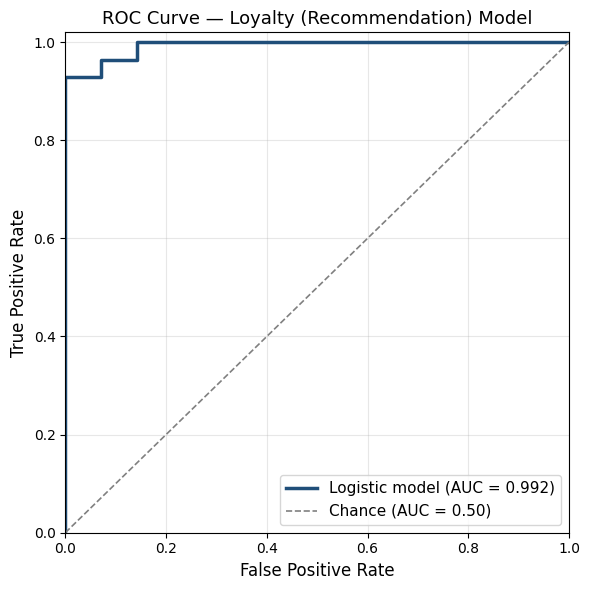

Saved roc_loyalty.png
                                coef  p_value  CI_low  CI_high  odds_ratio
value_money_rating             1.729    0.000   0.801    2.658       5.637
cabin_staff_rating             1.526    0.001   0.648    2.403       4.598
ground_service_rating          0.741    0.026   0.088    1.394       2.098
seat_comfort_rating            0.502    0.107  -0.108    1.112       1.652
food_beverages_rating          0.211    0.645  -0.688    1.110       1.235
inflight_entertainment_rating -0.217    0.505  -0.855    0.421       0.805


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, classification_report
import statsmodels.api as sm

# --- Rebuild the loyalty dataset (complete-case) ---
features = ['seat_comfort_rating','cabin_staff_rating','food_beverages_rating',
            'inflight_entertainment_rating','ground_service_rating','value_money_rating']
model_df = df_gulf.dropna(subset=features + ['recommended']).copy()
X = model_df[features]
y = model_df['recommended'].astype(int)
print("Complete-case rows:", len(model_df))

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
proba = clf.predict_proba(X_te)[:, 1]
pred  = clf.predict(X_te)

auc = roc_auc_score(y_te, proba)
f1  = f1_score(y_te, pred)
print(f"AUC-ROC: {auc:.3f}   F1 (recommend): {f1:.3f}   Macro F1: {f1_score(y_te,pred,average='macro'):.3f}")
print(classification_report(y_te, pred, digits=3))

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_te, proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='#1F4E79', lw=2.5, label=f'Logistic model (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], color='grey', lw=1.2, ls='--', label='Chance (AUC = 0.50)')
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Loyalty (Recommendation) Model', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "roc_loyalty.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved roc_loyalty.png")

# --- Coefficient p-values + CIs ---
Xc = sm.add_constant(X)
logit = sm.Logit(y, Xc).fit(disp=0)
summary = pd.DataFrame({
    'coef': logit.params, 'p_value': logit.pvalues,
    'CI_low': logit.conf_int()[0], 'CI_high': logit.conf_int()[1],
}).drop('const')
summary['odds_ratio'] = np.exp(summary['coef'])
print(summary.sort_values('coef', ascending=False).round(3))

In [ ]:
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

features = ['seat_comfort_rating','cabin_staff_rating','food_beverages_rating',
            'inflight_entertainment_rating','ground_service_rating','value_money_rating']
mdf = df_gulf.dropna(subset=features+['recommended']).copy()
X, y = mdf[features].values, mdf['recommended'].astype(int).values

n_boot = 1000
aucs, coefs = [], []
rng = np.random.RandomState(42)
for _ in range(n_boot):
    Xb, yb = resample(X, y, random_state=rng.randint(1e9))
    if len(np.unique(yb)) < 2:      # skip degenerate resamples
        continue
    m = LogisticRegression(max_iter=1000).fit(Xb, yb)
    aucs.append(roc_auc_score(yb, m.predict_proba(Xb)[:,1]))
    coefs.append(m.coef_[0])

aucs = np.array(aucs); coefs = np.array(coefs)
print(f"Bootstrap AUC: mean {aucs.mean():.3f}, 95% CI [{np.percentile(aucs,2.5):.3f}, {np.percentile(aucs,97.5):.3f}]")
print("\nBootstrap coefficient 95% CIs (odds-ratio scale):")
for i, f in enumerate(features):
    lo, hi = np.percentile(coefs[:,i], [2.5, 97.5])
    stable = "stable" if (lo>0 or hi<0) else "crosses 0"
    print(f"  {f:32s} OR CI [{np.exp(lo):.2f}, {np.exp(hi):.2f}]  ({stable})")

Bootstrap AUC: mean 0.990, 95% CI [0.977, 0.999]

Bootstrap coefficient 95% CIs (odds-ratio scale):
  seat_comfort_rating              OR CI [0.99, 2.92]  (crosses 0)
  cabin_staff_rating               OR CI [1.83, 7.86]  (stable)
  food_beverages_rating            OR CI [0.68, 2.70]  (crosses 0)
  inflight_entertainment_rating    OR CI [0.50, 1.72]  (crosses 0)
  ground_service_rating            OR CI [1.26, 3.40]  (stable)
  value_money_rating               OR CI [2.07, 9.11]  (stable)


In [ ]:
# ---- Reviewer diagnostics: class balance, baseline, VIF, McFadden's pseudo-R² ----
import numpy as np, pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.proportion import proportion_confint
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

features = ['seat_comfort_rating','cabin_staff_rating','food_beverages_rating',
            'inflight_entertainment_rating','ground_service_rating','value_money_rating']
model_df = df_gulf.dropna(subset=features + ['recommended']).copy()
X = model_df[features]
y = model_df['recommended'].astype(int)

# 1. Class balance in the complete-case sample
vc = y.value_counts().sort_index(); N = len(y)
print(f'Complete cases (n={N}):')
print(f"  recommend=1: {vc.get(1,0)} ({100*vc.get(1,0)/N:.1f}%)")
print(f"  recommend=0: {vc.get(0,0)} ({100*vc.get(0,0)/N:.1f}%)")

# 2. Class balance in the held-out test set (same split as the model)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
tvc = y_te.value_counts().sort_index(); T = len(y_te)
print(f'\nTest set (n={T}):')
print(f"  recommend=1: {tvc.get(1,0)}")
print(f"  recommend=0: {tvc.get(0,0)}")

# 3. Majority-class baseline vs. model accuracy (+ Wilson CI)
clf = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
acc = accuracy_score(y_te, clf.predict(X_te))
maj = tvc.max(); maj_lbl = tvc.idxmax()
lo, hi = proportion_confint(int(round(acc*T)), T, alpha=0.05, method='wilson')
print(f'\nModel accuracy: {acc:.3f} ({int(round(acc*T))}/{T}); Wilson 95% CI [{lo:.3f}, {hi:.3f}]')
print(f'Majority-class baseline (always predict {maj_lbl}): {maj}/{T} = {100*maj/T:.1f}%')
print(f'Improvement over baseline: {100*acc - 100*maj/T:.1f} percentage points')

# 4. VIF for the six predictors
X_vif = sm.add_constant(X)
vif = pd.DataFrame({'Predictor': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]})
print('\nVIF (ignore the constant row):')
print(vif.to_string(index=False))

# 5. McFadden's pseudo-R²
logit = sm.Logit(y, sm.add_constant(X)).fit(disp=0)
print(f"\nMcFadden's pseudo-R²: {1 - logit.llf/logit.llnull:.4f}")

Complete cases (n=166):
  recommend=1: 110 (66.3%)
  recommend=0: 56 (33.7%)

Test set (n=42):
  recommend=1: 28
  recommend=0: 14

Model accuracy: 0.929 (39/42); Wilson 95% CI [0.810, 0.975]
Majority-class baseline (always predict 1): 28/42 = 66.7%
Improvement over baseline: 26.2 percentage points

VIF (ignore the constant row):
                    Predictor      VIF
                        const 1.000000
          seat_comfort_rating 2.390823
           cabin_staff_rating 2.615563
        food_beverages_rating 3.052405
inflight_entertainment_rating 1.920115
        ground_service_rating 2.268678
           value_money_rating 2.777189

McFadden's pseudo-R²: 0.7790


Sampled reviews: 1000
Missing overall_rating (excluded): 100
Reviews used: 900
true
POSITIVE    548
NEGATIVE    352
Name: count, dtype: int64

Agreement: 727/900 = 0.808  (Wilson 95% CI [0.781, 0.832])

Confusion matrix (rows = true, cols = predicted) [NEGATIVE, POSITIVE]:
[[325  27]
 [146 402]]
              precision    recall  f1-score   support

    NEGATIVE      0.690     0.923     0.790       352
    POSITIVE      0.937     0.734     0.823       548

    accuracy                          0.808       900
   macro avg      0.814     0.828     0.806       900
weighted avg      0.840     0.808     0.810       900

Signed BERT score vs overall_rating: r = 0.715, p = 9.6e-142, n = 900
Earliest review: 2004-04-04
Latest review:   2015-08-02
Missing/unparseable dates: 0

Reviews per year:
date
2004       5
2005       1
2006       3
2007       1
2008       4
2009       5
2010      40
2011      89
2012      94
2013     273
2014    1025
2015     580
Name: count, dtype: int64
       aspect  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

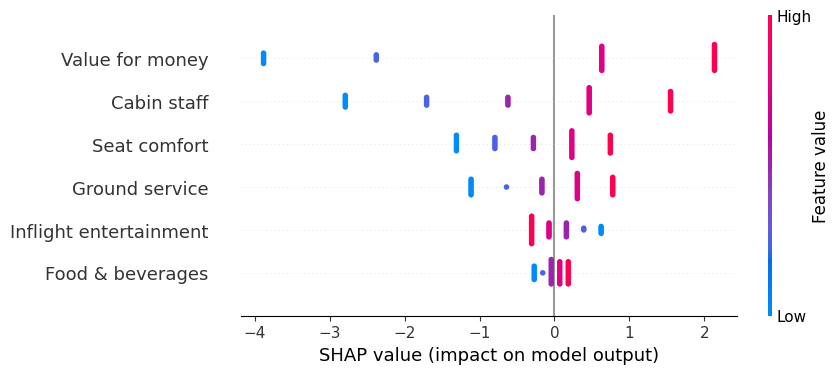

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

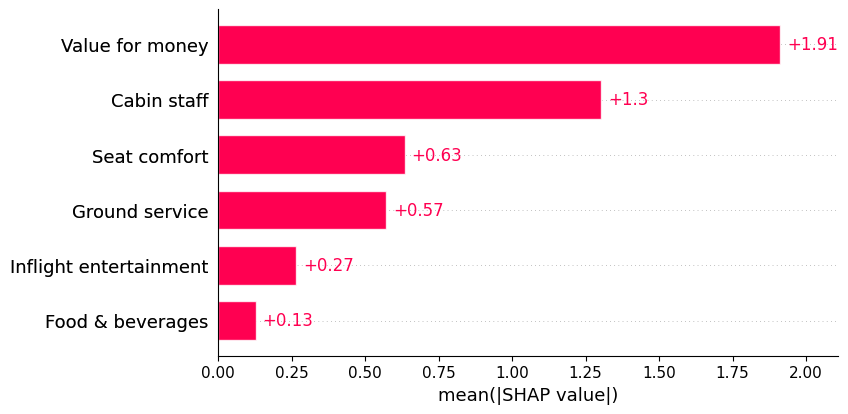

Although the lounge that Etihad uses in Manila is somewhat basic, the service on board the flight more than compensates. The aircraft flown was a 2 class 777 and my only complaint is that the seat is rather narrow for a substantial Westerner. The seat was however lie flat and was quite comfortable a
Predicted P(recommend): 0.994 | True label: 1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

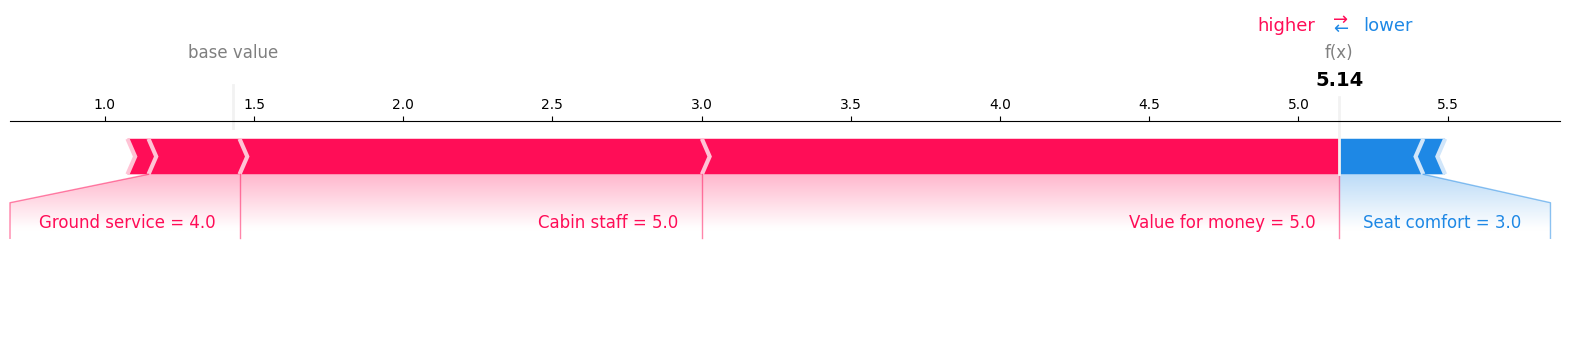

Valid resamples: 1000 of 1000
Apparent AUC (full data):     0.987
Mean optimism:                0.006
Optimism-corrected AUC:       0.982
Out-of-bag AUC: mean 0.976, 95% percentile CI [0.944, 0.997]

Odds ratios — 95% percentile bootstrap interval, and share of resamples with OR > 1:
  seat_comfort_rating              [0.98, 2.88]  includes 1  OR>1 in 96.3%
  cabin_staff_rating               [1.77, 8.09]  excludes 1  OR>1 in 100.0%
  food_beverages_rating            [0.69, 2.81]  includes 1  OR>1 in 76.6%
  inflight_entertainment_rating    [0.53, 1.65]  includes 1  OR>1 in 35.5%
  ground_service_rating            [1.22, 3.27]  excludes 1  OR>1 in 99.8%
  value_money_rating               [2.16, 8.66]  excludes 1  OR>1 in 100.0%
Python 3.13.15
transformers    5.16.1
torch           2.11.0+cu128
scikit-learn    1.6.1
shap            0.52.0
statsmodels     0.15.0
scipy           1.16.3
pandas          2.2.3
numpy           2.1.3
langdetect      1.0.9
vaderSentiment  3.3.2
GPU: Tesla T4


In [ ]:
# =====================================================================
# NEW CELLS FOR THE REVIEWER FIXES  (paste each block into its own Colab cell)
#
# Run these first in a fresh session:
#   cell 1  : drive.mount
#   cell 54 : load airline data -> df, df_gulf (2120)
#   cell 51 : load ABSA model  (add device=0)
#   cell 42 : airline document sentiment -> sample_df  (add device=0)
#   cell 60 : loyalty model -> clf, X_tr, X_te, features, model_df
# =====================================================================


# %% CELL A — Table 1: document-level validation on the AIRLINE sample
# (Reviewer 2: confusion matrix, binarisation rule, excluded reviews)
# Needs sample_df from cell 42 (airline data, random_state=42).
import numpy as np
from scipy import stats
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Sampled reviews:", len(sample_df))
print("Missing overall_rating (excluded):", sample_df['overall_rating'].isna().sum())

val = sample_df.dropna(subset=['overall_rating']).copy()
# Binarisation rule: overall_rating 1-10, >=6 positive, <=5 negative
val['true'] = np.where(val['overall_rating'] >= 6, 'POSITIVE', 'NEGATIVE')
print("Reviews used:", len(val))
print(val['true'].value_counts())

acc = accuracy_score(val['true'], val['bert_label'])
k = int((val['true'] == val['bert_label']).sum())
lo, hi = stats.binomtest(k, len(val)).proportion_ci(method='wilson')
print(f"\nAgreement: {k}/{len(val)} = {acc:.3f}  (Wilson 95% CI [{lo:.3f}, {hi:.3f}])")

print("\nConfusion matrix (rows = true, cols = predicted) [NEGATIVE, POSITIVE]:")
print(confusion_matrix(val['true'], val['bert_label'], labels=['NEGATIVE', 'POSITIVE']))
print(classification_report(val['true'], val['bert_label'], digits=3))

r, p = stats.pearsonr(val['bert_score'], val['overall_rating'])
print(f"Signed BERT score vs overall_rating: r = {r:.3f}, p = {p:.2g}, n = {len(val)}")


# %% CELL B — Dataset date range (Reviewer 1)
d = pd.to_datetime(df_gulf['date'], errors='coerce')
print("Earliest review:", d.min().date())
print("Latest review:  ", d.max().date())
print("Missing/unparseable dates:", d.isna().sum())
print("\nReviews per year:")
print(d.dt.year.value_counts().sort_index())


# %% CELL C — ABSA validation re-run with the SAME whole-word matching as cell 55
# Replaces cell 57 and the hard-coded numbers in cell 58.
# Needs: absa (cell 51), patterns (cell 55), df_gulf.
truth_map = {
    'cabin_crew':    'cabin_staff_rating',
    'food':          'food_beverages_rating',
    'seat_comfort':  'seat_comfort_rating',
    'entertainment': 'inflight_entertainment_rating',
    'value':         'value_money_rating',
    'boarding':      'ground_service_rating',   # rename key if you switch to 'ground_service'
}

def r_stats(r, n):
    t = r * np.sqrt((n - 2) / (1 - r**2))
    p = 2 * stats.t.sf(abs(t), df=n - 2)
    z, se = np.arctanh(r), 1 / np.sqrt(n - 3)
    return p, np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)

val_rows = []
for asp, col in truth_map.items():
    sub = df_gulf.dropna(subset=[col])
    items = [(str(t)[:512], rt) for t, rt in zip(sub['content'], sub[col])
             if patterns[asp].search(str(t)[:512])]
    if len(items) < 10:
        continue
    out = absa([{"text": t, "text_pair": asp.replace('_', ' ')} for t, _ in items],
               batch_size=32, top_k=None, truncation=True, max_length=512)
    scores = []
    for o in out:
        s = {d_['label']: d_['score'] for d_ in o}
        scores.append(s.get('Positive', 0) - s.get('Negative', 0))
    r = np.corrcoef(scores, [rt for _, rt in items])[0, 1]
    n = len(items)
    p, lo, hi = r_stats(r, n)
    val_rows.append({'aspect': asp, 'r': r, 'ci_low': lo, 'ci_high': hi, 'p': p, 'n': n})

val_tab = pd.DataFrame(val_rows).sort_values('r', ascending=False)
print(val_tab.round(3).to_string(index=False))
print(f"\nRange r = {val_tab['r'].min():.2f}-{val_tab['r'].max():.2f}, mean {val_tab['r'].mean():.2f}")
val_tab.to_csv(os.path.join(folder_path, "absa_validation_table.csv"), index=False)


# %% CELL D — SHAP figures, high resolution + download
import shap, matplotlib.pyplot as plt
from google.colab import files

nice = {'seat_comfort_rating': 'Seat comfort', 'cabin_staff_rating': 'Cabin staff',
        'food_beverages_rating': 'Food & beverages', 'inflight_entertainment_rating': 'Inflight entertainment',
        'ground_service_rating': 'Ground service', 'value_money_rating': 'Value for money'}
names = [nice.get(f, f) for f in features]

masker = shap.maskers.Independent(X_tr, max_samples=len(X_tr))
explainer = shap.Explainer(clf, masker)
sv = explainer(X_te)
sv.feature_names = names

def save(name):
    fig = plt.gcf()
    for ext in ("png", "pdf"):
        path = os.path.join(folder_path, f"{name}.{ext}")
        fig.savefig(path, dpi=300, bbox_inches='tight')
        files.download(path)
    plt.show(); plt.close('all')

# Fig 2 – global summary (beeswarm)
shap.plots.beeswarm(sv, show=False)
save("fig2_shap_summary")

# Optional – mean |SHAP| bar chart
shap.plots.bar(sv, show=False)
save("shap_bar_optional")

# Fig 3 – force plot for one test review
i = 0
print(model_df.loc[X_te.index[i], 'content'][:300])
print("Predicted P(recommend):", round(clf.predict_proba(X_te.iloc[[i]])[0, 1], 3),
      "| True label:", model_df.loc[X_te.index[i], 'recommended'])
shap.force_plot(sv.base_values[i], sv.values[i], X_te.iloc[i].values,
                feature_names=names, matplotlib=True, show=False)
save("fig3_shap_force")


# %% CELL E — Bootstrap with out-of-bag AUC + optimism correction (Reviewer 1)
# Replaces cell 61 (which scored AUC on the same bootstrap sample it was fit on).
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

mdf = df_gulf.dropna(subset=features + ['recommended']).copy()
X, y = mdf[features].values, mdf['recommended'].astype(int).values
n = len(y)

full = LogisticRegression(max_iter=1000).fit(X, y)
apparent = roc_auc_score(y, full.predict_proba(X)[:, 1])

rng = np.random.RandomState(42)
optimism, oob_aucs, coefs = [], [], []
for _ in range(1000):
    idx = rng.randint(0, n, n)
    oob = np.setdiff1d(np.arange(n), idx)
    if len(np.unique(y[idx])) < 2 or len(np.unique(y[oob])) < 2:
        continue
    m = LogisticRegression(max_iter=1000).fit(X[idx], y[idx])
    auc_boot = roc_auc_score(y[idx], m.predict_proba(X[idx])[:, 1])
    auc_orig = roc_auc_score(y, m.predict_proba(X)[:, 1])
    optimism.append(auc_boot - auc_orig)
    oob_aucs.append(roc_auc_score(y[oob], m.predict_proba(X[oob])[:, 1]))
    coefs.append(m.coef_[0])

optimism, oob_aucs, coefs = map(np.array, (optimism, oob_aucs, coefs))
print(f"Valid resamples: {len(coefs)} of 1000")
print(f"Apparent AUC (full data):     {apparent:.3f}")
print(f"Mean optimism:                {optimism.mean():.3f}")
print(f"Optimism-corrected AUC:       {apparent - optimism.mean():.3f}")
print(f"Out-of-bag AUC: mean {oob_aucs.mean():.3f}, "
      f"95% percentile CI [{np.percentile(oob_aucs, 2.5):.3f}, {np.percentile(oob_aucs, 97.5):.3f}]")

print("\nOdds ratios — 95% percentile bootstrap interval, and share of resamples with OR > 1:")
for j, f in enumerate(features):
    lo, hi = np.exp(np.percentile(coefs[:, j], [2.5, 97.5]))
    share = (coefs[:, j] > 0).mean()
    flag = "excludes 1" if (lo > 1 or hi < 1) else "includes 1"
    print(f"  {f:32s} [{lo:.2f}, {hi:.2f}]  {flag:10s}  OR>1 in {share:.1%}")


# %% CELL F — Exact package versions (Reviewer 1)
import sys, torch
from importlib.metadata import version
print("Python", sys.version.split()[0])
for pkg in ["transformers", "torch", "scikit-learn", "shap", "statsmodels", "scipy",
            "pandas", "numpy", "langdetect", "vaderSentiment"]:
    try:
        print(f"{pkg:15s} {version(pkg)}")
    except Exception:
        print(f"{pkg:15s} not installed")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

In [ ]:
# =====================================================================
# CELL G — EXTRA STATISTICAL CHECKS (paste each block into its own cell)
# Run in the same session as cells A–F (needs df_gulf, absa, patterns,
# folder_path). G2 re-scores ~4,300 aspect mentions: a few minutes on T4.
# =====================================================================

# %% G1 — Do the aspects really differ? (Kruskal–Wallis + delay vs each aspect)
import os
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

try:
    absa_df
except NameError:
    absa_df = pd.read_csv(os.path.join(folder_path, "gulf_absa_sentiment.csv"))

groups = {a: g['score'].values for a, g in absa_df.groupby('aspect')}
H, p_kw = stats.kruskal(*groups.values())
N, k = len(absa_df), len(groups)
eta2_H = (H - k + 1) / (N - k)
print(f"Kruskal–Wallis: H({k-1}) = {H:.1f}, p = {p_kw:.2g}, eta²_H = {eta2_H:.3f}, N = {N}")

d = groups['delay']
rows = []
for a, g in groups.items():
    if a == 'delay':
        continue
    U, p = stats.mannwhitneyu(d, g, alternative='two-sided')
    r_rb = 2 * U / (len(d) * len(g)) - 1          # rank-biserial; negative = delay lower
    rows.append({'delay_vs': a, 'U': U, 'p_raw': p, 'rank_biserial': r_rb,
                 'median_delay': np.median(d), 'median_other': np.median(g)})
pw = pd.DataFrame(rows)
pw['p_holm'] = multipletests(pw['p_raw'], method='holm')[1]
print("\nDelay vs each other aspect (Mann–Whitney U, Holm-adjusted):")
print(pw.sort_values('rank_biserial').round(4).to_string(index=False))
pw.to_csv(os.path.join(folder_path, "aspect_pairwise_delay.csv"), index=False)


# %% G2 — ABSA validation: Pearson + Spearman, both Holm-adjusted
truth_map = {
    'cabin_crew':    'cabin_staff_rating',
    'food':          'food_beverages_rating',
    'seat_comfort':  'seat_comfort_rating',
    'entertainment': 'inflight_entertainment_rating',
    'value':         'value_money_rating',
    'boarding':      'ground_service_rating',
}

val_rows, per_review = [], []
for asp, col in truth_map.items():
    sub = df_gulf.dropna(subset=[col])
    items = [(str(t)[:512], rt) for t, rt in zip(sub['content'], sub[col])
             if patterns[asp].search(str(t)[:512])]
    out = absa([{"text": t, "text_pair": asp.replace('_', ' ')} for t, _ in items],
               batch_size=32, top_k=None, truncation=True, max_length=512)
    scores = []
    for o in out:
        s = {x['label']: x['score'] for x in o}
        scores.append(s.get('Positive', 0) - s.get('Negative', 0))
    ratings = [rt for _, rt in items]
    r, p_r = stats.pearsonr(scores, ratings)
    rho, p_s = stats.spearmanr(scores, ratings)
    val_rows.append({'aspect': asp, 'n': len(items), 'pearson_r': r, 'p_pearson': p_r,
                     'spearman_rho': rho, 'p_spearman': p_s})
    per_review += [{'aspect': asp, 'absa': s_, 'rating': rt} for s_, rt in zip(scores, ratings)]

vt = pd.DataFrame(val_rows)
vt['p_pearson_holm'] = multipletests(vt['p_pearson'], method='holm')[1]
vt['p_spearman_holm'] = multipletests(vt['p_spearman'], method='holm')[1]
pd.set_option('display.float_format', lambda v: f"{v:.3g}")
print(vt.sort_values('pearson_r', ascending=False).to_string(index=False))
print("\n(p-values printed as 0 are < 1e-300; report them as p < 0.001)")
vt.to_csv(os.path.join(folder_path, "absa_validation_pearson_spearman.csv"), index=False)
pd.DataFrame(per_review).to_csv(os.path.join(folder_path, "absa_validation_per_review.csv"), index=False)
pd.reset_option('display.float_format')


# %% G3 — Repeated stratified 5-fold CV for the recommendation model (5 x 10 = 50 folds)
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

features = ['seat_comfort_rating', 'cabin_staff_rating', 'food_beverages_rating',
            'inflight_entertainment_rating', 'ground_service_rating', 'value_money_rating']
mdf = df_gulf.dropna(subset=features + ['recommended']).copy()
Xg, yg = mdf[features], mdf['recommended'].astype(int)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
res = cross_validate(LogisticRegression(max_iter=1000), Xg, yg, cv=cv,
                     scoring={'accuracy': 'accuracy', 'auc': 'roc_auc',
                              'f1_recommend': 'f1', 'f1_macro': 'f1_macro'})
print(f"Repeated stratified 5-fold CV (10 repeats, n = {len(yg)}):")
for m in ['accuracy', 'auc', 'f1_recommend', 'f1_macro']:
    v = res[f'test_{m}']
    print(f"  {m:13s} mean {v.mean():.3f}  SD {v.std(ddof=1):.3f}  "
          f"range [{v.min():.3f}, {v.max():.3f}]")
print(f"  Majority-class baseline accuracy: {max(yg.mean(), 1 - yg.mean()):.3f}")


# %% G4 — Is the model better than always predicting 'recommend'? (exact McNemar)
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(Xg, yg, test_size=0.25,
                                          random_state=42, stratify=yg)
clf = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
pred = clf.predict(X_te)
base = np.ones_like(y_te.values)                       # always predict 1
yt = y_te.values

b = int(((pred == yt) & (base != yt)).sum())           # model right, baseline wrong
c = int(((pred != yt) & (base == yt)).sum())           # model wrong, baseline right
p_mcnemar = stats.binomtest(b, b + c, 0.5).pvalue
print(f"Model accuracy {np.mean(pred == yt):.3f} vs baseline {np.mean(base == yt):.3f} (n = {len(yt)})")
print(f"Discordant pairs: model-only correct = {b}, baseline-only correct = {c}")
print(f"Exact McNemar test: p = {p_mcnemar:.4f}")


# %% G5 — Holm correction for the six Table 4 coefficients
import statsmodels.api as sm

logit = sm.Logit(yg, sm.add_constant(Xg)).fit(disp=0)
pv = logit.pvalues.drop('const')
t4 = pd.DataFrame({'odds_ratio': np.exp(logit.params.drop('const')),
                   'p_raw': pv,
                   'p_holm': multipletests(pv, method='holm')[1]})
print("Table 4 with Holm-adjusted p-values:")
print(t4.sort_values('p_raw').round(4))

Kruskal–Wallis: H(7) = 381.2, p = 2.6e-78, eta²_H = 0.062, N = 6067

Delay vs each other aspect (Mann–Whitney U, Holm-adjusted):
     delay_vs        U  p_raw  rank_biserial  median_delay  median_other  p_holm
        value  23719.0    0.0        -0.5934        -0.814        0.7935     0.0
entertainment  87694.0    0.0        -0.5714        -0.814        0.7872     0.0
         food 185834.0    0.0        -0.4720        -0.814        0.6968     0.0
     boarding  90055.0    0.0        -0.4678        -0.814        0.3513     0.0
 seat_comfort 173446.0    0.0        -0.4449        -0.814        0.5731     0.0
   cabin_crew 225753.0    0.0        -0.3468        -0.814        0.4490     0.0
      baggage  53847.0    0.0        -0.3465        -0.814       -0.0052     0.0
       aspect    n  pearson_r  p_pearson  spearman_rho  p_spearman  p_pearson_holm  p_spearman_holm
   cabin_crew 1164      0.762  3.61e-221         0.743   4.61e-205       2.16e-220        2.76e-204
        value  204     